# X-RAY POC

## Instructions for running the notebook

In order to run this notebook, start by executing the **initialize** section. this step must always be run.

The **download and prepare the dataset** section should only be executed if you want to recreate the dataset and upload it to drive. If the dataset already exists in drive, you can skip this section and continue with the rest of the notebook.

Make sure to first train the **head model** before running the **fine-tuning model**, since the fine-tuning stage depends on the trained head model.

If you choose to save the model, make sure to change the file name or path to avoid overwriting an existing model.

## Initialize

In [1]:
!rm -rf /content/images/
!rm -rf /content/labels.csv
!rm -rf /content/images.zip
!rm -rf /content/Data_Entry_2017_v2020.csv

In [2]:
!pip install ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.9 MB/s eta 0:00:00
time: 228 µs (started: 2026-05-01 14:26:21 +00:00)


## Download and prepare the dataset

In [ ]:
# install libraries
!pip install wget
!pip install -q gdown

# import modules and classes
import pandas as pd
import os
import tarfile
import wget
import gdown
import numpy as np
import shutil
import requests
from PIL import Image

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=7de8437de85f9c604d09d9aee4fb5b5b2ff1b938a10501340b23295d4532eb4d
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
time: 14.3 s (started: 2026-04-18 15:38:51 +00:00)


In [ ]:
# Download the CSV that links between classes to image file names
url = f"https://drive.google.com/uc?id=1QGFqCe07VRIWZI7VsMza1KYwzkTXtjw0"
gdown.download(url, "Data_Entry_2017_v2020.csv", quiet=False)

# Create pandas object
df = pd.read_csv("Data_Entry_2017_v2020.csv")

# Save only the columns we are interested in
df = df[["Image Index", "Finding Labels", "Patient ID"]]

print("Total rows:", len(df))
df.head()

Downloading...
From: https://drive.google.com/uc?id=1QGFqCe07VRIWZI7VsMza1KYwzkTXtjw0
To: /content/Data_Entry_2017_v2020.csv
100%|██████████| 9.00M/9.00M [00:00<00:00, 30.4MB/s]


Total rows: 112120


,Image Index,Finding Labels,Patient ID
0,00000001_000.png,Cardiomegaly,1
1,00000001_001.png,Cardiomegaly|Emphysema,1
2,00000001_002.png,Cardiomegaly|Effusion,1
3,00000002_000.png,No Finding,2
4,00000003_001.png,Hernia,3


time: 2.53 s (started: 2026-04-18 15:41:56 +00:00)


In [ ]:
# The classes we want to check
target_classes = ["Infiltration","Effusion", "Atelectasis"]

# Create vector that represent the classes of the image
def encode_labels(label_string):
    labels = [0] * len(target_classes)
    for i, disease in enumerate(target_classes):
        if disease in label_string:
            labels[i] = 1
    return labels

# Filter no-finding class
def filter_relevant(label_string):
    if "No Finding" in label_string:
        return True
    return any(disease in label_string for disease in target_classes)

# Remove vectors that are not in at least one of the classes we want
df = df[df["Finding Labels"].apply(filter_relevant)].copy()

# create df["labels"] - each element is a vector of the classes its belong to
df["labels"] = df["Finding Labels"].apply(encode_labels)

print("Total rows remaining:", len(df))
print(df.head())

Total rows remaining: 95831
         Image Index         Finding Labels  Patient ID     labels
2   00000001_002.png  Cardiomegaly|Effusion           1  [0, 1, 0]
3   00000002_000.png             No Finding           2  [0, 0, 0]
6   00000003_003.png    Hernia|Infiltration           3  [1, 0, 0]
13  00000005_000.png             No Finding           5  [0, 0, 0]
14  00000005_001.png             No Finding           5  [0, 0, 0]
time: 255 ms (started: 2026-04-18 16:00:36 +00:00)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Group split by patients - 64/16/20
gss_train = GroupShuffleSplit(n_splits=1, train_size=0.64, random_state=42)
train_idx, temp_idx = next(gss_train.split(df, groups=df['Patient ID']))

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

val_ratio_in_temp = 16 / (16 + 20)
gss_val = GroupShuffleSplit(n_splits=1, train_size=val_ratio_in_temp, random_state=42)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['Patient ID']))

df.loc[train_df.index, 'split'] = 'train'
df.loc[temp_df.iloc[val_idx].index, 'split'] = 'val'
df.loc[temp_df.iloc[test_idx].index, 'split'] = 'test'

print(f"Final Split Distribution:")
print(f"Train: {len(df[df['split']=='train'])} images ({len(df[df['split']=='train'])/len(df):.1%})")
print(f"Val:   {len(df[df['split']=='val'])} images ({len(df[df['split']=='val'])/len(df):.1%})")
print(f"Test:  {len(df[df['split']=='test'])} images ({len(df[df['split']=='test'])/len(df):.1%})")

Final Split Distribution:
Train: 60974 images (63.6%)
Val:   15253 images (15.9%)
Test:  19604 images (20.5%)
time: 223 ms (started: 2026-04-18 17:17:38 +00:00)


In [ ]:
import numpy as np

label_counts = np.zeros(3)

for label in df["labels"]:
    label_counts += np.array(label)

print("Number of images per label:")
for i, name in enumerate(target_classes):
    print(f"{name}: {int(label_counts[i])}")

Number of images per label:
Infiltration: 19894
Effusion: 13317
Atelectasis: 11559
time: 403 ms (started: 2026-04-18 17:19:11 +00:00)


In [ ]:
links = [
'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz',
'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz',
'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz',
'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz',
'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz',
'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz',
'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz',
'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz',
'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4c24eazhh281pbu.gz'
]

time: 1.14 ms (started: 2026-04-18 17:19:31 +00:00)


In [ ]:
os.makedirs("images", exist_ok=True)

time: 1.3 ms (started: 2026-04-18 17:19:38 +00:00)


In [ ]:
wanted_images = set(df["Image Index"]) # Image file names we want in the CSV
IMG_SIZE = 224
saved_counter = 0

for i, link in enumerate(links):
    # For each link, download the compressed file with images
    tar_name = f"images_{i}.tar.gz"
    print("Downloading:", tar_name)
    os.system(f"wget -O {tar_name} {link}")

    # Extract the images file
    print("Extracting:", tar_name)
    with tarfile.open(tar_name, "r:gz") as tar:
        # For each image in the tar file
        for member in tar.getmembers():
            filename = os.path.basename(member.name)

            # Check that the file name exist in the CSV
            if filename == "" or not filename.lower().endswith(".png"):
                print(f"The file '{filename}' in '{tar_name}' does not exist in the CSV or not of PNG type")
                continue

            # Filter the images that are not in the classes we want
            if filename not in wanted_images:
                continue

            # Check that the file is not None
            file_obj = tar.extractfile(member)
            if file_obj is None:
                print(f"The file '{filename}' in '{tar_name}' is None")
                continue

            # Open the image and convert to RGB
            img = Image.open(file_obj).convert("RGB")

            # Resize the image to (IMG_SIZE, IMG_SIZE, 3)
            img = img.resize((IMG_SIZE, IMG_SIZE))

            # normalize pixels from scale of 0-255 to scal of 0.0-1.0
            img = np.array(img) / 255.0

            # cancel the normalization for saving the image and save it in images/ folder
            save_img = (img * 255).astype(np.uint8)
            Image.fromarray(save_img).save(f"images/{filename}")

            saved_counter += 1

    # Remove the tar file
    print("Removing:", tar_name)
    os.remove(tar_name)

    print("Saved images:", saved_counter)

Downloading: images_0.tar.gz
Extracting: images_0.tar.gz
The file 'images' in 'images_0.tar.gz' does not exist in the CSV or not of PNG type
Removing: images_0.tar.gz
Saved images: 4214
Downloading: images_1.tar.gz
Extracting: images_1.tar.gz
The file 'images' in 'images_1.tar.gz' does not exist in the CSV or not of PNG type
Removing: images_1.tar.gz
Saved images: 12833
Downloading: images_2.tar.gz
Extracting: images_2.tar.gz
The file 'images' in 'images_2.tar.gz' does not exist in the CSV or not of PNG type
Removing: images_2.tar.gz
Saved images: 21357
Downloading: images_3.tar.gz
Extracting: images_3.tar.gz
The file 'images' in 'images_3.tar.gz' does not exist in the CSV or not of PNG type
Removing: images_3.tar.gz
Saved images: 29834
Downloading: images_4.tar.gz
Extracting: images_4.tar.gz
The file 'images' in 'images_4.tar.gz' does not exist in the CSV or not of PNG type
Removing: images_4.tar.gz
Saved images: 38390
Downloading: images_5.tar.gz
Extracting: images_5.tar.gz
The file 

Image: 00028795_002.png
Label vector: [0, 1, 1]
Classes: ['Infiltration', 'Effusion']
Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.9490196078431372
----
Image: 00028795_002.png
Label vector: [0, 0, 0]
Classes: []
Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.9490196078431372
----
Image: 00028795_002.png
Label vector: [0, 0, 0]
Classes: []
Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.9490196078431372
----
Image: 00028795_002.png
Label vector: [0, 0, 0]
Classes: []
Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.9490196078431372
----
Image: 00028795_002.png
Label vector: [0, 0, 0]
Classes: []
Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.9490196078431372
----
Image: 00028795_002.png
Label vector: [0, 0, 0]
Classes: []
Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.9490196078431372
----
Image: 00028795_002.png
Label vector: [0, 1, 0]
Classes: ['Infiltration']
Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.9490196078431372
----
Image: 00028795_002.png
Label vector: [0, 1

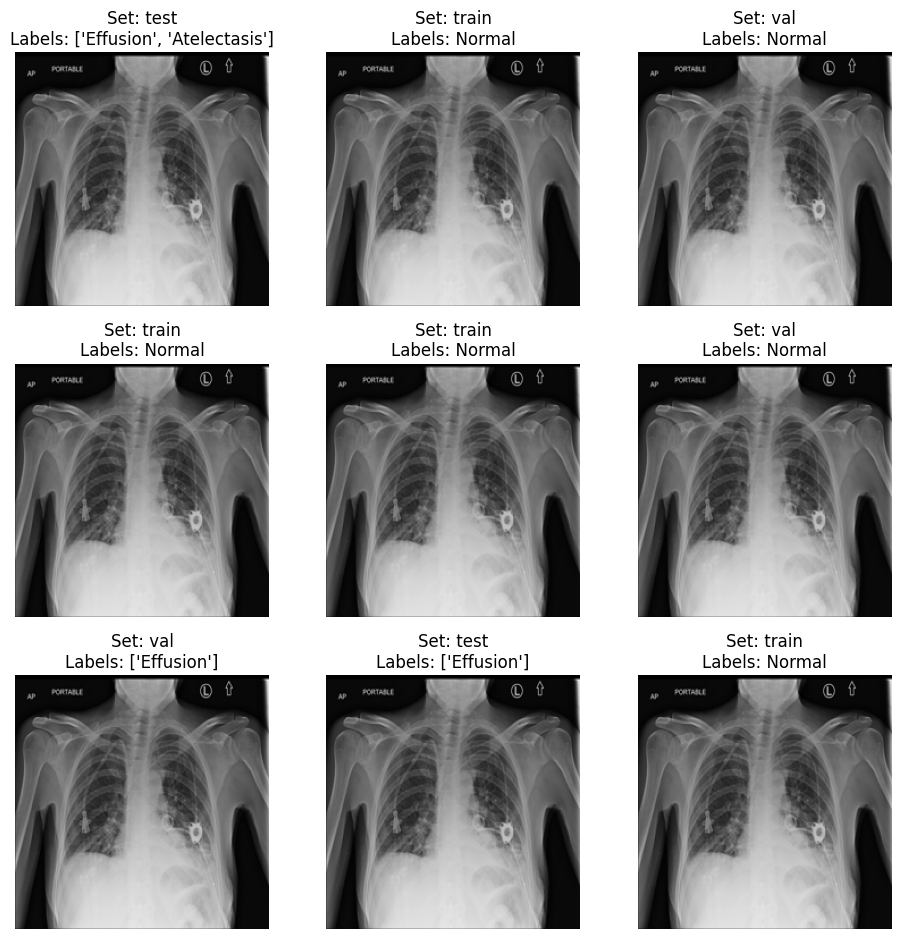

time: 912 ms (started: 2026-04-18 19:30:57 +00:00)


In [ ]:
available_imgs = os.listdir("images")
sample_df = df[df['Image Index'].isin(available_imgs)].sample(9)

plt.figure(figsize=(9.5, 9.5))
for i, (idx, row) in enumerate(sample_df.iterrows()):
    img = Image.open(f"images/{row['Image Index']}")

    img = Image.open(path)
    img = np.array(img) / 255.0 # Same normalization as perforemed before

    # Print the file name
    print("Image:", img_name)

    # Print the label vector
    label = row["labels"]
    print("Label vector:", label)

    # Print the Classes of the image
    active_labels = [class_names[j] for j,v in enumerate(label) if v==1]
    print("Classes:", active_labels)

    # Print the size of the image
    print("Shape:", img.shape)

    # Print the minimum and maximum pixel value after normalization
    print("Min pixel:", img.min())
    print("Max pixel:", img.max())

    print("----")

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    active = [target_classes[j] for j, v in enumerate(row['labels']) if v == 1]
    plt.title(f"Set: {row['split']}\nLabels: {active if active else 'Normal'}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Save link between the images we want to the class labels + the vector that represent the classes of the image into new CSV file
df.to_csv("labels.csv", index=False)

# Contert the images folder to zip
!zip -r images.zip images

Streaming output truncated to the last 5000 lines.
  adding: images/00028649_000.png (deflated 0%)
  adding: images/00001395_014.png (deflated 0%)
  adding: images/00029279_004.png (deflated 0%)
  adding: images/00026963_008.png (deflated 0%)
  adding: images/00005631_001.png (deflated 2%)
  adding: images/00017963_004.png (deflated 0%)
  adding: images/00018412_007.png (deflated 0%)
  adding: images/00023100_000.png (deflated 0%)
  adding: images/00002300_046.png (deflated 0%)
  adding: images/00020381_000.png (deflated 0%)
  adding: images/00021066_002.png (deflated 0%)
  adding: images/00000519_000.png (deflated 0%)
  adding: images/00011877_007.png (deflated 0%)
  adding: images/00007569_002.png (deflated 0%)
  adding: images/00024055_000.png (deflated 0%)
  adding: images/00008814_009.png (deflated 0%)
  adding: images/00019869_000.png (deflated 0%)
  adding: images/00016042_005.png (deflated 0%)
  adding: images/00029469_010.png (deflated 0%)
  adding: images/00014996_015.png (de

## Download the prepared dataset and labels from drive

In [3]:
# install gdown
!pip install gdown

import gdown
import zipfile
import pandas as pd
import os
import ast

time: 5.2 s (started: 2026-05-01 14:26:21 +00:00)


In [4]:
# Download the CSV labels from drive and load it into pandas object
csv_id = "1VuwkoaO8N0qIvt6MGDp5204QHW8cIv7U"
gdown.download(id=csv_id, output="labels.csv", quiet=False)

df = pd.read_csv("labels.csv")
df["labels"] = df["labels"].apply(ast.literal_eval)

print("Total rows:", len(df))
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1VuwkoaO8N0qIvt6MGDp5204QHW8cIv7U
To: /content/labels.csv
100%|██████████| 5.20M/5.20M [00:00<00:00, 24.7MB/s]


Total rows: 95831
        Image Index         Finding Labels  Patient ID     labels  split
0  00000001_002.png  Cardiomegaly|Effusion           1  [0, 1, 0]  train
1  00000002_000.png             No Finding           2  [0, 0, 0]  train
2  00000003_003.png    Hernia|Infiltration           3  [1, 0, 0]  train
3  00000005_000.png             No Finding           5  [0, 0, 0]   test
4  00000005_001.png             No Finding           5  [0, 0, 0]   test
time: 3.58 s (started: 2026-05-01 14:26:26 +00:00)


In [5]:
# Download the zip images and unzip it
zip_id = "1666QrMHKqnY25Eu-gBJ9nX3wwauz1omH"
gdown.download(id=zip_id, output="images.zip", quiet=False)

!unzip images.zip
print("Total images:", len(os.listdir("images")))

Downloading...
From (original): https://drive.google.com/uc?id=1666QrMHKqnY25Eu-gBJ9nX3wwauz1omH
From (redirected): https://drive.google.com/uc?id=1666QrMHKqnY25Eu-gBJ9nX3wwauz1omH&confirm=t&uuid=1a2187e4-97e9-4ab9-b429-da021c7135a9
To: /content/images.zip
100%|██████████| 3.48G/3.48G [01:18<00:00, 44.5MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: images/00001395_014.png  
  inflating: images/00029279_004.png  
  inflating: images/00026963_008.png  
  inflating: images/00005631_001.png  
  inflating: images/00017963_004.png  
  inflating: images/00018412_007.png  
  inflating: images/00023100_000.png  
  inflating: images/00002300_046.png  
  inflating: images/00020381_000.png  
  inflating: images/00021066_002.png  
  inflating: images/00000519_000.png  
  inflating: images/00011877_007.png  
  inflating: images/00007569_002.png  
  inflating: images/00024055_000.png  
  inflating: images/00008814_009.png  
  inflating: images/00019869_000.png  
  inflating: images/00016042_005.png  
  inflating: images/00029469_010.png  
  inflating: images/00014996_015.png  
  inflating: images/00017417_003.png  
  inflating: images/00022566_002.png  
  inflating: images/00020113_033.png  
  inflating: images/00002640_000.png  
  inflating: images/00016199_003.png  
  inflating: 

## Preparing the ground before training the model

In [6]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from PIL import Image
import ast

time: 3.49 s (started: 2026-05-01 14:28:27 +00:00)


In [7]:
train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 60974
Validation: 15253
Test: 19604
time: 54.6 ms (started: 2026-05-01 14:28:31 +00:00)


In [8]:
target_classes = ["Infiltration", "Effusion", "Atelectasis"]
def count_classes(df, name):
    labels = np.stack(df["labels"].values)
    counts = labels.sum(axis=0)
    print(f"\n{name} set:")
    normal_count = len(df) - np.sum(np.any(labels > 0, axis=1))
    for i, class_name in enumerate(target_classes):
        print(f"{class_name}: {counts[i]}")
    print(f"Normal (No Finding): {normal_count}")
    print("Total images:", len(df))

count_classes(train_df, "Train")
count_classes(val_df, "Validation")
count_classes(test_df, "Test")


Train set:
Infiltration: 12726
Effusion: 8483
Atelectasis: 7391
Normal (No Finding): 38367
Total images: 60974

Validation set:
Infiltration: 3048
Effusion: 2112
Atelectasis: 1807
Normal (No Finding): 9638
Total images: 15253

Test set:
Infiltration: 4120
Effusion: 2722
Atelectasis: 2361
Normal (No Finding): 12356
Total images: 19604
time: 143 ms (started: 2026-05-01 14:28:31 +00:00)


In [9]:
IMG_SIZE = 224

def load_image(filename, label):
    path = tf.strings.join(["images/", filename])
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    return img, label


time: 663 µs (started: 2026-05-01 14:28:31 +00:00)


In [10]:
BATCH_SIZE = 32

def create_dataset(dataframe, shuffle=False):
    filenames = dataframe["Image Index"].values
    labels = np.stack(dataframe["labels"].values).astype(np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((filenames, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

time: 683 µs (started: 2026-05-01 14:28:31 +00:00)


In [11]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

time: 1.52 s (started: 2026-05-01 14:28:31 +00:00)


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

time: 3.78 ms (started: 2026-05-01 14:28:33 +00:00)


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
])
print("All datasets and augmentation layers are ready for training.")

All datasets and augmentation layers are ready for training.
time: 15.6 ms (started: 2026-05-01 14:28:33 +00:00)


## Build the model

In [14]:
# include the blocks: conv1, conv2, conv3, conv4 and conv5
base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

print("Base model loaded and frozen.")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Base model loaded and frozen.
time: 6.41 s (started: 2026-05-01 14:28:33 +00:00)


In [15]:
from tensorflow.keras import layers, models

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
x = tf.keras.applications.densenet.preprocess_input(x) # includes pixel normalization
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(3, activation="sigmoid")(x)
model = models.Model(inputs, outputs)

time: 40.6 ms (started: 2026-05-01 14:28:39 +00:00)


## The head model

### Train the head

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

time: 374 µs (started: 2026-05-01 14:28:39 +00:00)


In [17]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels_mat = np.stack(train_df["labels"].values)
pos_counts = train_labels_mat.sum(axis=0)
neg_counts = len(train_labels_mat) - pos_counts

pos_weights_raw = neg_counts / pos_counts
pos_weights = np.sqrt(pos_weights_raw).astype(np.float32)

print("pos_counts:", pos_counts)
print("neg_counts:", neg_counts)
print("raw pos_weights (neg/pos):", pos_weights_raw)
print("used pos_weights (sqrt):  ", pos_weights)

pos_weights_tf = tf.constant(pos_weights, dtype=tf.float32)

def weighted_bce(y_true, y_pred):
    eps = 1e-7
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    loss = -(pos_weights_tf * y_true * tf.math.log(y_pred)
             + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    return tf.reduce_mean(loss)


pos_counts: [12726  8483  7391]
neg_counts: [48248 52491 53583]
raw pos_weights (neg/pos): [3.79129342 6.18778734 7.24976323]
used pos_weights (sqrt):   [1.9471244 2.4875264 2.6925385]
time: 96.6 ms (started: 2026-05-01 14:28:39 +00:00)


In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=weighted_bce,
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc", multi_label=True)]
)

time: 10.6 ms (started: 2026-05-01 14:28:40 +00:00)


In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop],
)

Epoch 1/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 104s 46ms/step - accuracy: 0.4944 - auc: 0.6919 - loss: 0.6869 - val_accuracy: 0.6382 - val_auc: 0.7251 - val_loss: 0.6437
Epoch 2/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.5756 - auc: 0.7362 - loss: 0.6401 - val_accuracy: 0.6454 - val_auc: 0.7379 - val_loss: 0.6302
Epoch 3/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.5863 - auc: 0.7481 - loss: 0.6277 - val_accuracy: 0.6553 - val_auc: 0.7410 - val_loss: 0.6285
Epoch 4/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.5992 - auc: 0.7567 - loss: 0.6191 - val_accuracy: 0.6582 - val_auc: 0.7443 - val_loss: 0.6259
Epoch 5/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.6061 - auc: 0.7597 - loss: 0.6159 - val_accuracy: 0.6696 - val_auc: 0.7474 - val_loss: 0.6228
Epoch 6/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.6103 - auc: 0.7651 - loss: 0.6109 - val_accuracy: 0.6641 - val_auc: 0.7479 - val_loss: 0.6224
Epoch 7/30
1906

In [20]:
print("number of layers in the network: ", len(base_model.layers))

number of layers in the network:  427
time: 591 µs (started: 2026-05-01 14:53:01 +00:00)


### Graphs

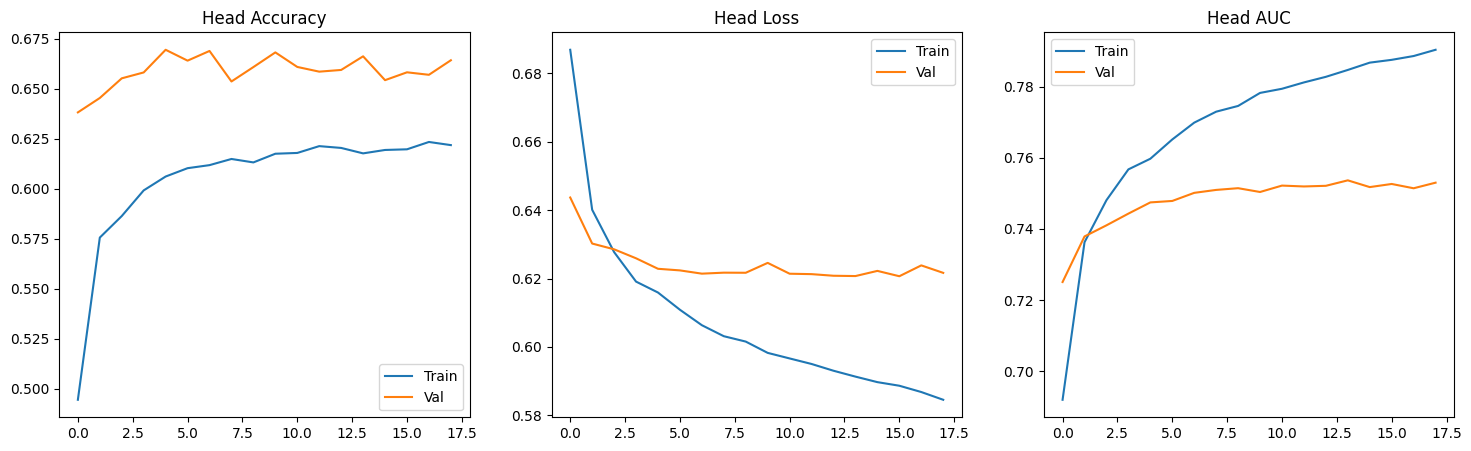

time: 426 ms (started: 2026-05-01 14:53:01 +00:00)


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Head Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Head Loss')
axes[1].legend()

# AUC
if 'auc' in history.history:
    axes[2].plot(history.history['auc'], label='Train')
    axes[2].plot(history.history['val_auc'], label='Val')
    axes[2].set_title('Head AUC')
    axes[2].legend()

plt.show()

### Save the head model

In [22]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define path to save model
MODEL_PATH = "/content/drive/MyDrive/xray_model_poc.keras"

# Save full model (architecture + weights + optimizer state)
model.save(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Mounted at /content/drive
Model saved to: /content/drive/MyDrive/xray_model_poc.keras
time: 22.2 s (started: 2026-05-01 14:53:18 +00:00)


## The fine-tuning model

### Train the model

In [24]:
base_model.trainable = True

# Last dense block + final BN/ReLU. Add "conv4_" later for a deeper unfreeze.
UNFREEZE_PREFIXES = ("conv5_",)

for layer in base_model.layers:
    if layer.name.startswith(UNFREEZE_PREFIXES) or layer.name in ("bn", "relu"):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

n_trainable = sum(layer.trainable for layer in base_model.layers)
print(f"Trainable layers in base: {n_trainable} / {len(base_model.layers)}")

Trainable layers in base: 81 / 427
time: 10.3 ms (started: 2026-05-01 14:54:20 +00:00)


In [25]:
for layer in model.layers:
    if layer.name.startswith("densenet"):
        print()
        print("(", layer.name, layer.trainable, ")")
        for layer2 in base_model.layers:
            print(layer2.name, layer2.trainable)
        print()
        continue
    print(layer.name, layer.trainable)

input_layer_1 True
sequential True

( densenet121 True )
input_layer False
zero_padding2d False
conv1_conv False
conv1_bn False
conv1_relu False
zero_padding2d_1 False
pool1 False
conv2_block1_0_bn False
conv2_block1_0_relu False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False
conv2_block1_2_conv False
conv2_block1_concat False
conv2_block2_0_bn False
conv2_block2_0_relu False
conv2_block2_1_conv False
conv2_block2_1_bn False
conv2_block2_1_relu False
conv2_block2_2_conv False
conv2_block2_concat False
conv2_block3_0_bn False
conv2_block3_0_relu False
conv2_block3_1_conv False
conv2_block3_1_bn False
conv2_block3_1_relu False
conv2_block3_2_conv False
conv2_block3_concat False
conv2_block4_0_bn False
conv2_block4_0_relu False
conv2_block4_1_conv False
conv2_block4_1_bn False
conv2_block4_1_relu False
conv2_block4_2_conv False
conv2_block4_concat False
conv2_block5_0_bn False
conv2_block5_0_relu False
conv2_block5_1_conv False
conv2_block5_1_bn False
conv2_bl

In [26]:
trainable_params = sum(
    int(tf.size(w)) for w in model.trainable_weights
)
total_params = sum(
    int(tf.size(w)) for w in model.weights
)
print(f"Trainable params: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.1f}%)")


Trainable params: 2,263,555 / 7,173,187 (31.6%)
time: 136 ms (started: 2026-05-01 14:55:28 +00:00)


In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss=weighted_bce,
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc", multi_label=True)]
)

time: 54 ms (started: 2026-05-01 14:55:32 +00:00)


In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

time: 864 µs (started: 2026-05-01 14:55:35 +00:00)


In [29]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 130s 58ms/step - accuracy: 0.6597 - auc: 0.7848 - loss: 0.5900 - val_accuracy: 0.6528 - val_auc: 0.7578 - val_loss: 0.6155
Epoch 2/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 104s 54ms/step - accuracy: 0.6460 - auc: 0.7893 - loss: 0.5848 - val_accuracy: 0.6384 - val_auc: 0.7607 - val_loss: 0.6093
Epoch 3/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 103s 54ms/step - accuracy: 0.6459 - auc: 0.7934 - loss: 0.5811 - val_accuracy: 0.6428 - val_auc: 0.7612 - val_loss: 0.6136
Epoch 4/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 103s 54ms/step - accuracy: 0.6442 - auc: 0.7956 - loss: 0.5777 - val_accuracy: 0.6367 - val_auc: 0.7628 - val_loss: 0.6089
Epoch 5/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 102s 54ms/step - accuracy: 0.6476 - auc: 0.7978 - loss: 0.5751 - val_accuracy: 0.6399 - val_auc: 0.7644 - val_loss: 0.6080
Epoch 6/30
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 103s 54ms/step - accuracy: 0.6470 - auc: 0.7996 - loss: 0.5728 - val_accuracy: 0.6440 - val_auc: 0.7651 - val_loss: 0.6069
Epoch 7/30

### Threshold tuning on the validation set

AUC is high but accuracy/F1 with a 0.5 threshold is low because the model's probabilities are not calibrated to that threshold. Pick a per-class threshold that maximises F1 on the validation set, then use those thresholds at test time.

In [30]:
from sklearn.metrics import f1_score
import numpy as np

print("Generating validation predictions for threshold tuning...")
val_pred_probs = model.predict(val_ds, verbose=0)

val_true_list = []
for _, labels in val_ds:
    val_true_list.append(labels.numpy())
val_true = np.concatenate(val_true_list, axis=0)

best_thresholds = np.zeros(len(target_classes), dtype=np.float32)
candidate_thresholds = np.linspace(0.05, 0.95, 91)

for i, name in enumerate(target_classes):
    f1s = [
        f1_score(val_true[:, i], (val_pred_probs[:, i] > t).astype(int), zero_division=0)
        for t in candidate_thresholds
    ]
    best_idx = int(np.argmax(f1s))
    best_thresholds[i] = candidate_thresholds[best_idx]
    print(f"{name:14s}  best threshold = {best_thresholds[i]:.2f}  "
          f"val F1 = {f1s[best_idx]:.3f}")

print("\nbest_thresholds:", best_thresholds)


Generating validation predictions for threshold tuning...
Infiltration    best threshold = 0.29  val F1 = 0.415
Effusion        best threshold = 0.44  val F1 = 0.514
Atelectasis     best threshold = 0.34  val F1 = 0.367

best_thresholds: [0.29 0.44 0.34]
time: 25 s (started: 2026-05-01 15:35:43 +00:00)


### Test the model

In [31]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

test_loss, _, test_auc_keras = model.evaluate(test_ds, verbose=1)
print(f"Keras test loss : {test_loss:.4f}")
print(f"Keras test AUC  : {test_auc_keras:.4f}")

print("\nGenerating test predictions...")
y_pred_probs = model.predict(test_ds, verbose=0)

y_true_list = []
for _, labels in test_ds:
    y_true_list.append(labels.numpy())
y_true = np.concatenate(y_true_list, axis=0)

# Apply the per-class thresholds tuned on validation
y_pred_binary = (y_pred_probs > best_thresholds[None, :]).astype(int)

print("\nPer-class metrics with tuned thresholds:")
for i, name in enumerate(target_classes):
    p = precision_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
    r = recall_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
    f = f1_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
    a = roc_auc_score(y_true[:, i], y_pred_probs[:, i])
    print(f"  {name:14s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  AUC={a:.3f}")

# Mean AUC across the 3 classes
mean_auc = np.mean([
    roc_auc_score(y_true[:, i], y_pred_probs[:, i])
    for i in range(len(target_classes))
])
print(f"\nMean per-class AUC: {mean_auc:.4f}")

613/613 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6358 - auc: 0.7712 - loss: 0.6126
Keras test loss : 0.6126
Keras test AUC  : 0.7712

Generating test predictions...

Per-class metrics with tuned thresholds:
  Infiltration    P=0.331  R=0.610  F1=0.429  AUC=0.697
  Effusion        P=0.409  R=0.640  F1=0.499  AUC=0.850
  Atelectasis     P=0.277  R=0.550  F1=0.368  AUC=0.767

Mean per-class AUC: 0.7712
time: 42 s (started: 2026-05-01 15:36:23 +00:00)


### Graphs

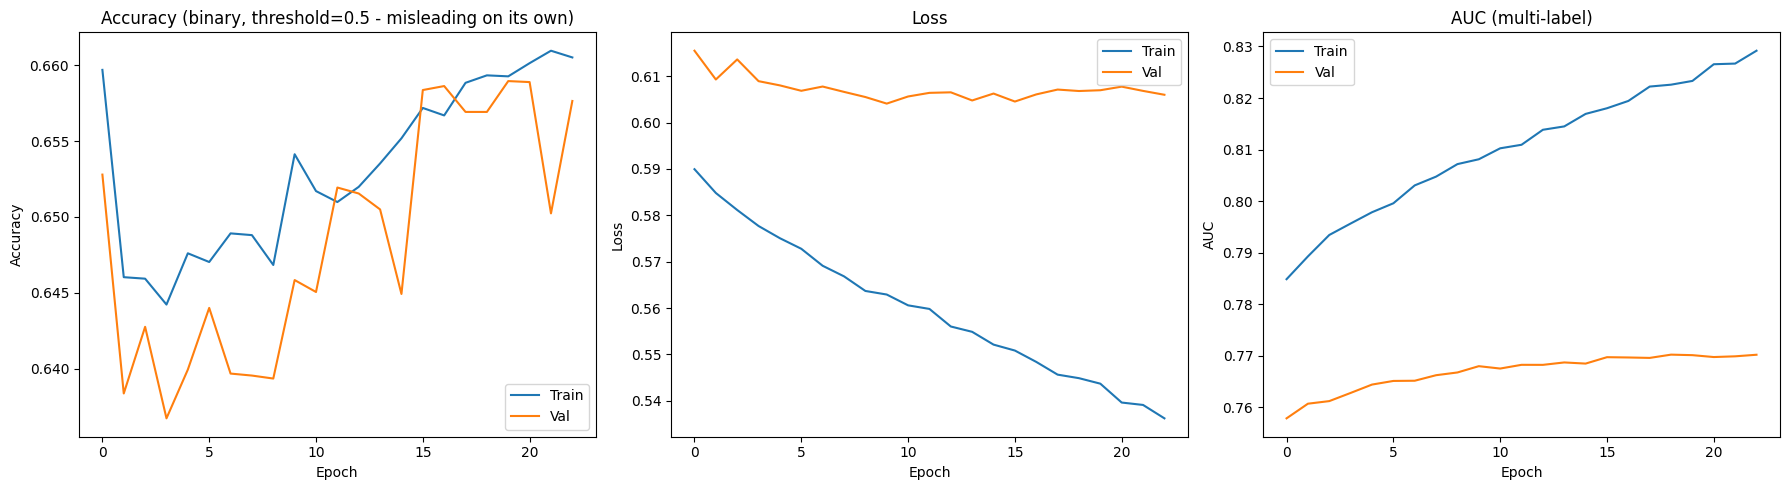

time: 436 ms (started: 2026-05-01 15:37:16 +00:00)


In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_fine.history['accuracy'], label='Train')
axes[0].plot(history_fine.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy (binary, threshold=0.5 - misleading on its own)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history_fine.history['loss'], label='Train')
axes[1].plot(history_fine.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

axes[2].plot(history_fine.history['auc'], label='Train')
axes[2].plot(history_fine.history['val_auc'], label='Val')
axes[2].set_title('AUC (multi-label)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC'); axes[2].legend()

plt.tight_layout()
plt.show()

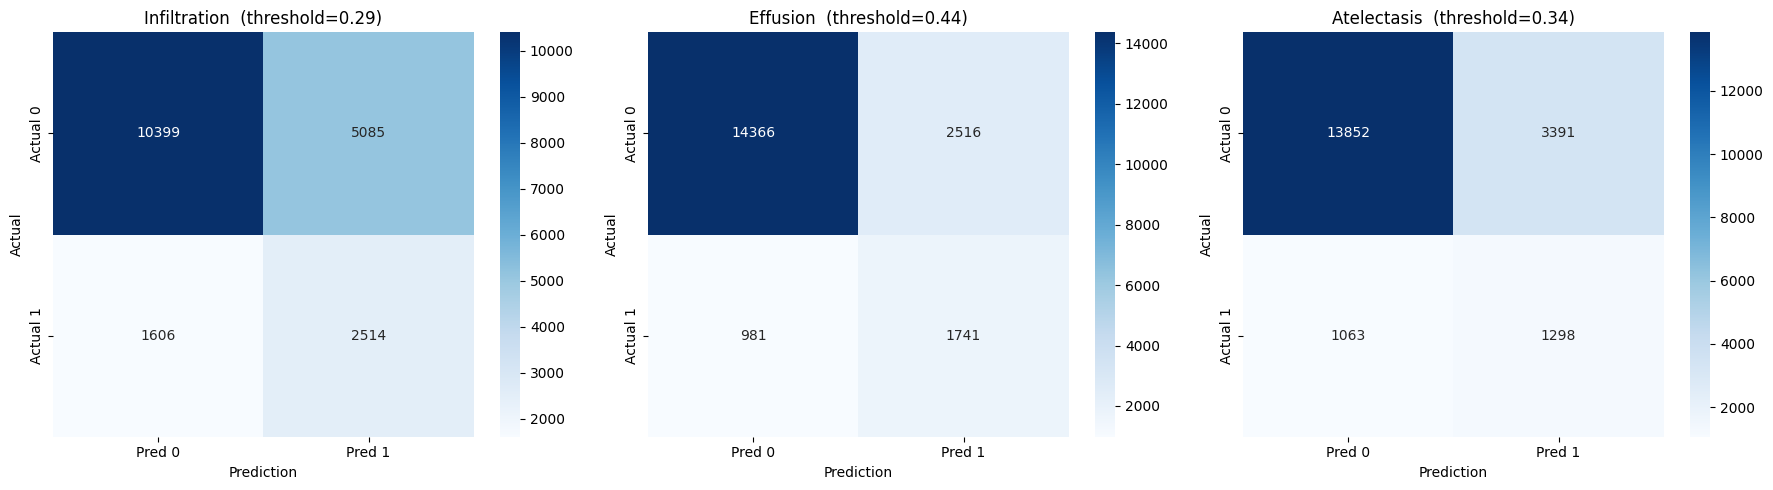

time: 894 ms (started: 2026-05-01 15:37:38 +00:00)


In [33]:
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# y_pred_probs and y_true were computed in the test-evaluation cell above.
y_pred_binary = (y_pred_probs > best_thresholds[None, :]).astype(int)

mcm = multilabel_confusion_matrix(y_true, y_pred_binary)

num_classes = len(target_classes)
fig, axes = plt.subplots(1, num_classes, figsize=(6 * num_classes, 5))
if num_classes == 1:
    axes = [axes]

for i, (matrix, name) in enumerate(zip(mcm, target_classes)):
    sns.heatmap(matrix, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    axes[i].set_title(f'{name}  (threshold={best_thresholds[i]:.2f})')
    axes[i].set_xlabel('Prediction'); axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import classification_report

# Re-using y_true and y_pred_probs from the evaluation cell.
y_pred_binary = (y_pred_probs > best_thresholds[None, :]).astype(int)

print("Classification report with TUNED per-class thresholds:")
print(classification_report(
    y_true,
    y_pred_binary,
    target_names=target_classes,
    zero_division=0,
))

print("\nFor comparison, with the old 0.5 threshold:")
y_pred_05 = (y_pred_probs > 0.5).astype(int)
print(classification_report(
    y_true,
    y_pred_05,
    target_names=target_classes,
    zero_division=0,
))

Classification report with TUNED per-class thresholds:
              precision    recall  f1-score   support

Infiltration       0.33      0.61      0.43      4120
    Effusion       0.41      0.64      0.50      2722
 Atelectasis       0.28      0.55      0.37      2361

   micro avg       0.34      0.60      0.43      9203
   macro avg       0.34      0.60      0.43      9203
weighted avg       0.34      0.60      0.43      9203
 samples avg       0.16      0.22      0.18      9203


For comparison, with the old 0.5 threshold:
              precision    recall  f1-score   support

Infiltration       0.46      0.25      0.32      4120
    Effusion       0.43      0.57      0.49      2722
 Atelectasis       0.34      0.31      0.33      2361

   micro avg       0.41      0.36      0.39      9203
   macro avg       0.41      0.38      0.38      9203
weighted avg       0.42      0.36      0.37      9203
 samples avg       0.12      0.13      0.12      9203

time: 41 ms (started: 2026-05-

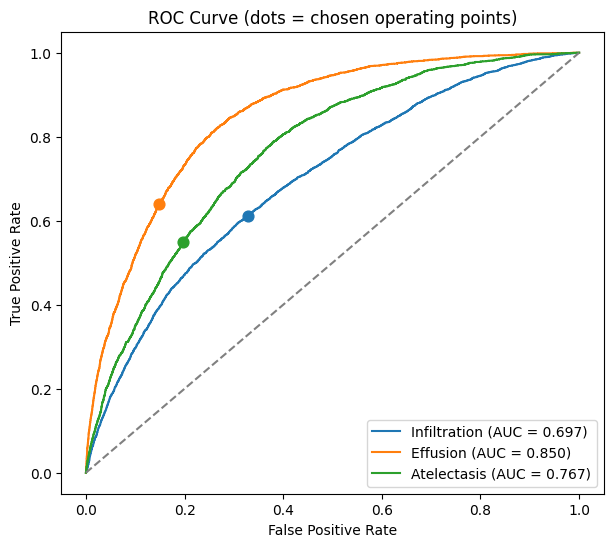

time: 215 ms (started: 2026-05-01 15:40:53 +00:00)


In [35]:
from sklearn.metrics import roc_curve, auc as sk_auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for i, class_name in enumerate(target_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    roc_auc = sk_auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

    op_pred = (y_pred_probs[:, i] > best_thresholds[i]).astype(int)
    tp = np.sum((op_pred == 1) & (y_true[:, i] == 1))
    fp = np.sum((op_pred == 1) & (y_true[:, i] == 0))
    fn = np.sum((op_pred == 0) & (y_true[:, i] == 1))
    tn = np.sum((op_pred == 0) & (y_true[:, i] == 0))
    op_tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    op_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    plt.scatter([op_fpr], [op_tpr], s=60, zorder=5)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (dots = chosen operating points)")
plt.legend()
plt.show()

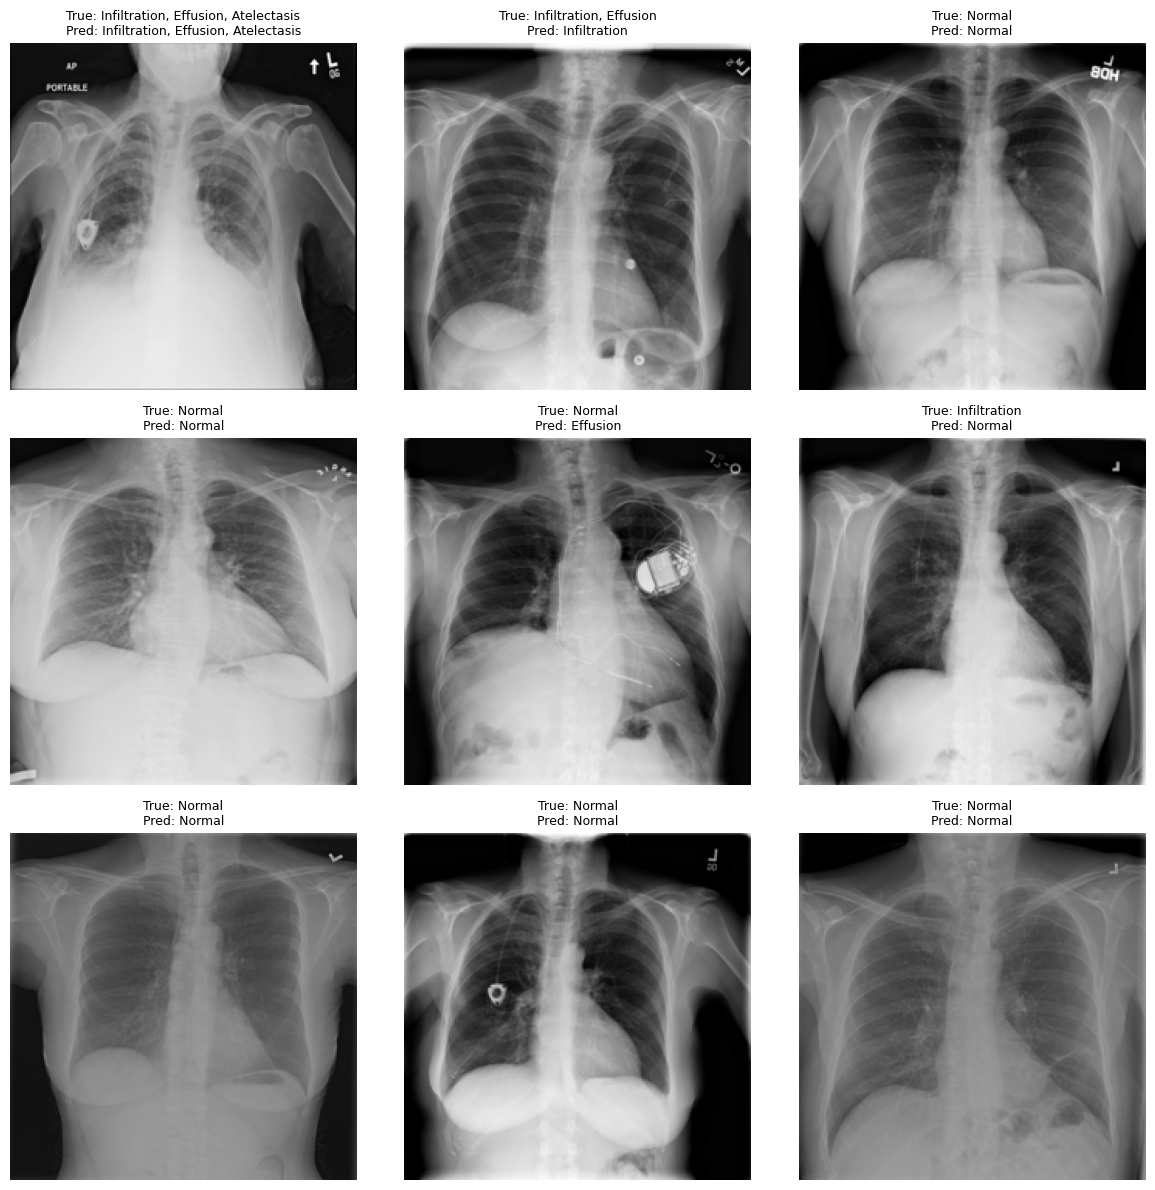

time: 973 ms (started: 2026-05-01 15:42:16 +00:00)


In [37]:
import random
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 12))

for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    pred_binary = (preds > best_thresholds[None, :]).astype(int)
    labels_np = labels.numpy().astype(int)

    n_show = min(9, len(images))
    indices = random.sample(range(len(images)), n_show)

    for i, idx in enumerate(indices):
        plt.subplot(3, 3, i + 1)
        img = images[idx].numpy()
        img = np.clip(img, 0, 255).astype("uint8")
        plt.imshow(img)

        true_labels = [target_classes[j] for j, v in enumerate(labels_np[idx]) if v == 1] or ["Normal"]
        pred_labels = [target_classes[j] for j, v in enumerate(pred_binary[idx]) if v == 1] or ["Normal"]
        plt.title(f"True: {', '.join(true_labels)}\nPred: {', '.join(pred_labels)}",
                  fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

### Save the fine-tuning model

In [38]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define path to save model
MODEL_PATH = "/content/drive/MyDrive/xray_model_fine_tuning_poc.keras"

# Save full model (architecture + weights + optimizer state)
model.save(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/xray_model_fine_tuning_poc.keras
time: 3.74 s (started: 2026-05-01 15:43:41 +00:00)
